importações

In [2]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np


path

In [3]:
PATH_IMAGE = r"C:\Users\luisf\Documents\brain-tumor-detection-yolov11\brain-tumor-detection-yolov11\data\train\images\1_jpg.rf.eee6547c09d13001fff4a45c380115aa.jpg"
caminhos_imagens = glob.glob("data/train/images/*.*")
PATH_TXT = r"C:\Users\luisf\Documents\brain-tumor-detection-yolov11\brain-tumor-detection-yolov11\data\train\labels\1_jpg.rf.eee6547c09d13001fff4a45c380115aa.txt"

func ler imagem

In [4]:
def load_image(path):
    """
    read a image from specified file path
    
    Args: path(str) - the path file
    Returns: None
    """
    # a command that can read the image path (have the parameter flags, but it's optional)
    image = cv2.imread(path)

    if image is None:
        print("Error: unable to read")

    # a function that can show the display a image 
    cv2.imshow("window", image)

    # a function that wait for a key press to close the window, if you put a number like 5000(ms) the window will keep 5 seconds open to close.
    cv2.waitKey(0)
    #obs: the destroyWindow() exist too
    cv2.destroyAllWindows()

funcao ler label

In [5]:
def read_label(path):
    """
    Read a label from specified file path

    Args: path(str) - the path of file
    Returns: 
    - label(list of str) - the list of label of the image path
    - a error
    """
    # the try is a secure form to realize the open, can raise a error
    try:
        # the with function already close the open without file.close()
        with open(path, "r") as file:
            # read the first line of file
            row = file.readline()

            # splits the row per space key and take it, that be the label
            # i change that, i was taken only the class, but now, is all the line splited. 
            label = row.split()
        return label
    
    except Exception as error:
        return f"Error: {error}"

func printar the bounding boxes

In [6]:
def show_boxes(path, path_txt):
    """
    show a image from specified file path with your segmentation instance
    
    Args: path(str) - the path file
    Returns: None
    """

    # reading the image and the row of .txt
    image = cv2.imread(path)
    label_numbers = read_label(path_txt)

    # here is a possible exeption
    if image is None or not label_numbers:
        print("Error: unable to read")

    class_id = label_numbers[0]
    # the variable '_' is color channels 
    high, weight, _ = image.shape

    # to show it, you need desnormalize the points of .txt, you need to put in a numpy array, because it's the form that cv2 aceppt
    pixel = []
    for i in range(1, len(label_numbers), 2):
        # transforming a string in a float
        x_normalized = float(label_numbers[i])
        y_normalized = float(label_numbers[i+1])

        # its tranformed by int because a pixel is a int number
        x_pixel = int(x_normalized * weight)
        y_pixel = int(y_normalized * high)

        pixel.append([x_pixel, y_pixel])

    # i saw that np.int32 will be necessary
    pixel_points_array = np.array(pixel, dtype=np.int32)
    # the cv2 accepts only a tridimensional matrix to do the polylines
    # -1 -> num of rows auto
    # 1 -> extra dimension
    # 2 -> num of columns
    pixel_points_array = pixel_points_array.reshape((-1, 1, 2))

    # i don't understand why the pixel_points have to be in a list if i already reshaped this, but ok
    cv2.polylines(image, [pixel_points_array], isClosed=True, color=(0, 255, 0), thickness=2)

    x, y, w, h = cv2.boundingRect(pixel_points_array)

    cv2.putText(image, class_id, (x, (y+h)), cv2.FONT_ITALIC, 0.6, (0, 255, 0), 2)
 
    plt.figure()
    plt.imshow(image)
    plt.axis('off')
    plt.show()

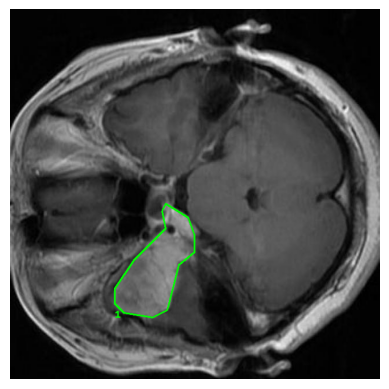

In [8]:
show_boxes(PATH_IMAGE, PATH_TXT)